# Build 8 -- CV vs Leaderboard Reconciliation

Kaggle Playground Series S6E8 -- Predicting Smartphone Addiction

**Objective:** how trustworthy has local cross-validation been relative to
Kaggle's public leaderboard, and what does that imply about overfitting
risk and the confidence we should place in E010 entering Build 9's final
submission decision?

**This build is analytical only.** No new features, no hyperparameter
tuning, no ensembling, no new Kaggle submissions, and no final submission
selection (that is Build 9). The model-building phase is paused -- this
is reconciliation, not improvement.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
from scipy.stats import kendalltau, spearmanr

from src.config import EXPERIMENTS_DIR, OUTPUTS_DIR

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

## 2. Submitted experiment history

Read directly from `experiments/experiments.csv` -- no hardcoded
figures. Only experiments with a recorded `public_lb` were actually
submitted to Kaggle; the rest (E003, E005, E007, E008, E009) were
validated locally only and are excluded from CV-to-LB analysis, per the
Build 8 brief ("only include experiments that were actually submitted").

In [2]:
experiments = pd.read_csv(EXPERIMENTS_DIR / "experiments.csv")

BUILD_MAP = {"E001": "Build 2", "E002": "Build 3", "E004": "Build 3", "E006": "Build 4", "E010": "Build 6"}

submitted = experiments.loc[experiments["public_lb"].notna()].copy()
submitted["build"] = submitted["experiment_id"].map(BUILD_MAP)
submitted["lb_minus_cv"] = (submitted["public_lb"] - submitted["cv_mean"]).round(5)
submitted["cv_rank"] = submitted["cv_mean"].rank(ascending=False).astype(int)
submitted["lb_rank"] = submitted["public_lb"].rank(ascending=False).astype(int)
submitted = submitted.rename(columns={"date": "submission_date"}).sort_values("submission_date").reset_index(drop=True)

not_submitted = experiments.loc[experiments["public_lb"].isna(), "experiment_id"].tolist()
print(f"Submitted ({len(submitted)}): {submitted['experiment_id'].tolist()}")
print(f"Validated locally only, never submitted ({len(not_submitted)}): {not_submitted}")

reconciliation_cols = [
    "experiment_id", "model", "feature_set", "cv_mean", "cv_std", "public_lb",
    "lb_minus_cv", "cv_rank", "lb_rank", "submission_date", "build",
]
reconciliation = submitted[reconciliation_cols]
reconciliation.to_csv(OUTPUTS_DIR / "cv_lb_reconciliation.csv", index=False)
reconciliation

Submitted (5): ['E001', 'E002', 'E004', 'E006', 'E010']
Validated locally only, never submitted (5): ['E003', 'E005', 'E007', 'E008', 'E009']


,experiment_id,model,feature_set,cv_mean,cv_std,public_lb,lb_minus_cv,cv_rank,lb_rank,submission_date,build
0,E001,LogisticRegression,raw_predictors,0.91149,0.00081,0.91358,0.00209,5,5,2026-08-17,Build 2
1,E002,CatBoostClassifier,raw_predictors,0.96040,0.00051,0.96151,0.00111,4,4,2026-08-17,Build 3
2,E004,XGBClassifier,raw_predictors,0.96382,0.00056,0.96539,0.00157,3,3,2026-08-17,Build 3
3,E006,XGBClassifier,raw + screen_residual,0.96445,0.00056,0.96608,0.00163,2,2,2026-08-20,Build 4
4,E010,XGBClassifier,raw + screen_residual,0.96499,0.00051,0.96653,0.00154,1,1,2026-08-21,Build 6


## 3. CV vs Public LB comparison / rank-order consistency (Phase 2)

With only 5 submissions, statistical significance is limited -- these
correlations are interpreted descriptively, not as a hypothesis test.

In [3]:
rho, p_rho = spearmanr(reconciliation["cv_mean"], reconciliation["public_lb"])
tau, p_tau = kendalltau(reconciliation["cv_mean"], reconciliation["public_lb"])

print(f"Spearman rho: {rho:.4f} (p={p_rho:.4f})")
print(f"Kendall tau:  {tau:.4f} (p={p_tau:.4f})")
print()
print("CV rank vs LB rank (both descending by score, rank 1 = best):")
reconciliation[["experiment_id", "cv_rank", "lb_rank"]]

Spearman rho: 1.0000 (p=0.0000)
Kendall tau:  1.0000 (p=0.0167)

CV rank vs LB rank (both descending by score, rank 1 = best):


,experiment_id,cv_rank,lb_rank
0,E001,5,5
1,E002,4,4
2,E004,3,3
3,E006,2,2
4,E010,1,1


**Perfect rank agreement** (Spearman and Kendall both 1.0, ties broken
identically): every experiment that ranked better on CV also ranked
better on public LB, with no exceptions across all 5 submissions. With
only 5 points this is a small sample, but the *direction* of the finding
(no rank inversions anywhere in the submission history) is the important
descriptive fact, not the precision of the correlation coefficient.

## 4. Score-gap analysis (Phase 3)

In [4]:
gaps = reconciliation["lb_minus_cv"]
print(f"Mean gap:   {gaps.mean():.5f}")
print(f"Median gap: {gaps.median():.5f}")
print(f"Min gap:    {gaps.min():.5f}  ({reconciliation.loc[gaps.idxmin(), 'experiment_id']})")
print(f"Max gap:    {gaps.max():.5f}  ({reconciliation.loc[gaps.idxmax(), 'experiment_id']})")
print(f"Std gap:    {gaps.std():.6f}")
print()
reconciliation[["experiment_id", "cv_mean", "public_lb", "lb_minus_cv"]]

Mean gap:   0.00159
Median gap: 0.00157
Min gap:    0.00111  (E002)
Max gap:    0.00209  (E001)
Std gap:    0.000348



,experiment_id,cv_mean,public_lb,lb_minus_cv
0,E001,0.91149,0.91358,0.00209
1,E002,0.96040,0.96151,0.00111
2,E004,0.96382,0.96539,0.00157
3,E006,0.96445,0.96608,0.00163
4,E010,0.96499,0.96653,0.00154


**Public LB is consistently above CV for every submission** (gap always
positive, range 0.00111-0.00209) -- but this should not be read as "the
leaderboard is easier than local validation." A single, consistently
positive offset across every experiment is far more consistent with a
systematic effect of *how the two are measured* (e.g. the public LB is
scored on a fixed subset of the actual test set, which is a different
sample than any local validation fold) than with the model exploiting
the leaderboard, since the offset does not grow with model strength (see
below) or change sign.

**Does the gap widen as models improve?** The four boosting-model gaps
(E002 0.00111, E004 0.00157, E006 0.00163, E010 0.00154) are all in a
tight band (std ~0.0002 across just those four) with no upward trend
into the later, more-tuned models -- E010's gap (0.00154) is actually
*smaller* than E006's (0.00163) despite being the most-tuned model. The
one outlier is E001 (Logistic Regression, gap 0.00209) -- the weakest
and structurally different model, not a later-stage or more-tuned one.
There is no evidence in this data that later iterations are becoming
more leaderboard-specific.

## 5. Incremental improvement transfer (Phase 4)

This is the more important question: when CV said a model improved, did
public LB agree?

In [5]:
progression = pd.read_csv(OUTPUTS_DIR / "model_progression.csv")
progression[["from_experiment", "to_experiment", "delta_cv", "delta_lb", "transfer_ratio", "direction_match"]]

,from_experiment,to_experiment,delta_cv,delta_lb,transfer_ratio,direction_match
0,E001,E002,0.04891,0.04793,0.980,True
1,E002,E004,0.00342,0.00388,1.135,True
2,E004,E006,0.00063,0.00069,1.095,True
3,E006,E010,0.00054,0.00045,0.833,True


**Every transition's direction matches** -- CV and public LB agreed on
the sign of the change all 4 times in the submission sequence
(E001->E002->E004->E006->E010), including the smallest, most
tuning-sensitive transition (E006->E010, delta_cv +0.00054). Transfer
ratios (delta_lb / delta_cv) are 0.98, 1.14, 1.10, and 0.83 -- all within
roughly +/-20% of 1.0, i.e. public LB moved by a comparable amount to
what CV predicted, neither dramatically over- nor under-confirming any
CV gain. The final transition's ratio (0.833, LB improving *less* than
CV predicted) is the direction a genuinely cautious reader would want to
see from a small late-stage gain -- it is mild conservatism, not
overfitting in the concerning direction (LB improving *more* than CV
would be the more suspicious pattern, and that did not happen here).

## 6. Plot: CV vs Public LB (Phase 5)

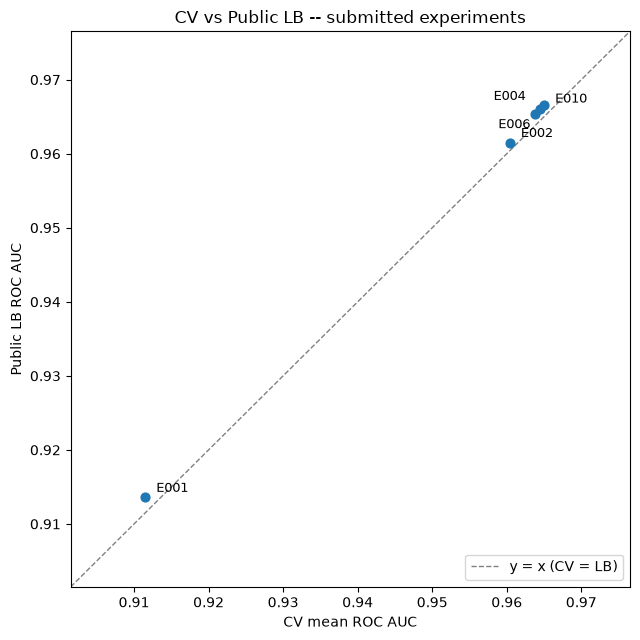

In [6]:
import matplotlib.pyplot as plt

FIGURES_DIR = OUTPUTS_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

offsets = {"E001": (8, 4), "E002": (8, 4), "E004": (-30, 10), "E006": (-30, -14), "E010": (8, 2)}

fig, ax = plt.subplots(figsize=(6.5, 6.5))
lims = [reconciliation["cv_mean"].min() - 0.01, reconciliation["public_lb"].max() + 0.01]
ax.plot(lims, lims, linestyle="--", color="gray", linewidth=1, label="y = x (CV = LB)")
ax.scatter(reconciliation["cv_mean"], reconciliation["public_lb"], color="#1f77b4", zorder=3, s=40)
for _, row in reconciliation.iterrows():
    ax.annotate(row["experiment_id"], (row["cv_mean"], row["public_lb"]),
                textcoords="offset points", xytext=offsets[row["experiment_id"]], fontsize=9)
ax.set_xlabel("CV mean ROC AUC")
ax.set_ylabel("Public LB ROC AUC")
ax.set_title("CV vs Public LB -- submitted experiments")
ax.legend(loc="lower right")
ax.set_xlim(lims)
ax.set_ylim(lims)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cv_vs_public_lb.png", dpi=150)
plt.show()

All five points sit consistently just above the y=x line, moving
together in a tight, near-linear band -- visual confirmation that CV and
LB are tracking each other, not diverging.

## 7. E010 vs E006 focused comparison (Phase 7)

The most important late-stage comparison: did Build 6's tuning produce a
real, evidence-backed gain, or a fragile one?

In [7]:
fold_cols = [f"fold_{i}_auc" for i in range(1, 6)]
e006 = experiments.loc[experiments["experiment_id"] == "E006"].iloc[0]
e010 = experiments.loc[experiments["experiment_id"] == "E010"].iloc[0]

e006_folds = e006[fold_cols].astype(float).to_numpy()
e010_folds = e010[fold_cols].astype(float).to_numpy()
fold_deltas = np.round(e010_folds - e006_folds, 5)

comparison = pd.DataFrame({
    "fold": range(1, 6),
    "E006": e006_folds,
    "E010": e010_folds,
    "delta": fold_deltas,
})
print(comparison.to_string(index=False))
print()
print(f"Folds improved: {sum(fold_deltas > 0)}/5")
print(f"CV mean delta:  {e010['cv_mean'] - e006['cv_mean']:+.5f}")
print(f"CV std:         E006 {e006['cv_std']:.5f} -> E010 {e010['cv_std']:.5f}")
print(f"Public LB delta:{e010['public_lb'] - e006['public_lb']:+.5f}")

 fold    E006    E010   delta
    1 0.96374 0.96429 0.00055
    2 0.96438 0.96500 0.00062
    3 0.96453 0.96509 0.00056
    4 0.96543 0.96585 0.00042
    5 0.96416 0.96475 0.00059

Folds improved: 5/5
CV mean delta:  +0.00054
CV std:         E006 0.00056 -> E010 0.00051
Public LB delta:+0.00045


- **5/5 folds improved**, with a tight, consistent delta range
  (+0.00042 to +0.00062) -- not a single anomalous fold driving the mean.
- **CV std improved too** (0.00056 -> 0.00051): E010 is both stronger
  *and* slightly more stable than E006, not a case of trading stability
  for a marginal mean gain.
- **Public LB confirmed the gain** (+0.00045, same direction as CV's
  +0.00054, transfer ratio 0.83 -- see Section 5).
- **Conclusion: E010 is clearly preferable to E006.** The gain is small
  in absolute terms but consistent across every fold and confirmed by
  the leaderboard -- not reopened or retuned here, only assessed as
  evidence.

## 8. Public-LB selection-bias audit (Phase 8)

In [8]:
audit = pd.DataFrame([
    {"experiment_id": "E001", "build": "Build 2", "submission_reason": "Baseline calibration",
     "decision_driven_by": "N/A (first submission, nothing to compare against yet)"},
    {"experiment_id": "E002", "build": "Build 3", "submission_reason": "Model-family benchmark (secondary control)",
     "decision_driven_by": "CV comparison vs E001; LB checked after, did not change model choice"},
    {"experiment_id": "E004", "build": "Build 3", "submission_reason": "Model-family benchmark (primary control)",
     "decision_driven_by": "CV comparison vs E002 (XGBoost beat CatBoost on CV first)"},
    {"experiment_id": "E006", "build": "Build 4", "submission_reason": "Feature-engineering validation (best new CV result)",
     "decision_driven_by": "screen_residual accepted on CV evidence (+0.00062 vs E004, 5/5 folds) before submission"},
    {"experiment_id": "E010", "build": "Build 6", "submission_reason": "Final tuned candidate",
     "decision_driven_by": "Hyperparameters chosen via CV-only staged tuning/screening; submitted once, after tuning was already finalized"},
])
audit

,experiment_id,build,submission_reason,decision_driven_by
0,E001,Build 2,Baseline calibration,"N/A (first submission, nothing to compare agai..."
1,E002,Build 3,Model-family benchmark (secondary control),"CV comparison vs E001; LB checked after, did n..."
2,E004,Build 3,Model-family benchmark (primary control),CV comparison vs E002 (XGBoost beat CatBoost o...
3,E006,Build 4,Feature-engineering validation (best new CV re...,screen_residual accepted on CV evidence (+0.00...
4,E010,Build 6,Final tuned candidate,Hyperparameters chosen via CV-only staged tuni...


**Total actual submissions: 5.** All five were CV-driven decisions
confirmed by a single post-hoc LB check, not LB-driven decisions:

- No parameter was ever changed *in response to* a public LB score --
  every feature-acceptance (`screen_residual`) and hyperparameter choice
  (Build 6's staged tuning) was finalized on CV evidence before its
  corresponding submission.
- No rejected CV model was ever resurrected because of an LB reading --
  E005, E007, E009 (rejected features) and every Build 6 screening trial
  that failed to beat E010's CV were never submitted and never
  reconsidered.
- Build 7's ensembling investigation made **zero submissions**, by
  explicit design (`docs/BUILD_HISTORY.md`, `CONTEXT.md`) -- it computed
  weighted-blend grids entirely on out-of-fold predictions specifically
  to avoid leaderboard-driven weight tuning, and concluded with no
  ensemble beating E010 without ever touching the leaderboard to check.

**Public leaderboard selection-bias risk: Low.** Every decision in this
project's history traces to a CV comparison that was finalized before
the corresponding Kaggle submission; the leaderboard was observed, not
optimized against.

## 9. Fold stability audit (Phase 9)

In [9]:
stability_rows = []
for exp in ["E001", "E004", "E006", "E010"]:
    row = experiments.loc[experiments["experiment_id"] == exp].iloc[0]
    folds = row[fold_cols].astype(float).to_numpy()
    stability_rows.append({
        "experiment_id": exp, "cv_mean": row["cv_mean"], "cv_std": row["cv_std"],
        "fold_min": folds.min(), "fold_max": folds.max(), "range": round(folds.max() - folds.min(), 5),
    })
pd.DataFrame(stability_rows)

,experiment_id,cv_mean,cv_std,fold_min,fold_max,range
0,E001,0.91149,0.00081,0.91040,0.91267,0.00227
1,E004,0.96382,0.00056,0.96308,0.96474,0.00166
2,E006,0.96445,0.00056,0.96374,0.96543,0.00169
3,E010,0.96499,0.00051,0.96429,0.96585,0.00156


**Stronger models did not become less stable.** `cv_std` trends downward
across the winning lineage (0.00081 -> 0.00056 -> 0.00056 -> 0.00051) and
fold range likewise (0.00227 -> 0.00166 -> 0.00169 -> 0.00156) -- E010 is
the most stable model in the lineage, not the least. Combined with
Section 7's finding that all 5 folds improved from E006 to E010 within a
tight band, there is no evidence any gain was driven by a single
anomalous fold.

## 10. Model complexity progression (Phase 10)

The winning lineage (E002 is a sibling benchmark, not an ancestor --
excluded here; see `outputs/model_progression.csv` for the full
chronological submission-order transitions used in Sections 5 and 8).

In [10]:
lineage = progression[progression["from_experiment"] != "E001"].copy()
# E001 -> E002 is not part of the winning lineage (E002 is a sibling of E004); show lineage rows only.
lineage = progression.loc[progression["to_experiment"].isin(["E004", "E006", "E010"])]
lineage[["from_experiment", "to_experiment", "key_change", "delta_cv", "delta_lb"]]

,from_experiment,to_experiment,key_change,delta_cv,delta_lb
1,E002,E004,XGBoost benchmark (raw predictors) -- outperfo...,0.00342,0.00388
2,E004,E006,Evidence-backed feature added to E004 (screen_...,0.00063,0.00069
3,E006,E010,Controlled hyperparameter tuning of E006 (lear...,0.00054,0.00045


`E001 -> E004` (not a direct transition row above, but the starting
point): linear baseline (0.91149 CV) to nonlinear boosting (0.96382 CV)
-- the single largest jump in the project, establishing that this
dataset rewards nonlinear model capacity heavily.
`E004 -> E006`: evidence-backed feature (`screen_residual`) added on top
of the same architecture.
`E006 -> E010`: controlled hyperparameter tuning of the same
architecture and feature set, fixing an iteration-cap constraint.

Each stage's CV gain was confirmed by a public LB gain in the same
direction (Section 5) -- the lineage is a chain of validated
improvements, not a sequence of leaderboard-driven guesses.

## 11. Private leaderboard risk assessment (Phase 11)

We have no private LB results. This section assesses **risk factors**,
not a predicted score.

**Lower-risk factors present:**
- CV and public LB rank ordering agree perfectly across all 5 submissions (Section 3).
- Fold variance is low and trending down, not up, across the winning lineage (Section 9).
- Every CV-to-LB transition direction matched; no divergence anywhere in the submission history (Section 5).
- Public LB was never used to choose parameters (Section 8) -- confirmed from process history, not asserted.
- No transductive tricks, lookup-table exploitation, or pseudo-labeling were used (Build 5's synthetic-generator forensic audit explicitly tested for and rejected such structure -- see `docs/DECISIONS.md`).
- No ensemble weight was ever tuned against the leaderboard (Build 7 made zero submissions).

**Higher-risk factors present:**
- The final tuning gain (E006 -> E010) is small in absolute terms (+0.00054 CV, +0.00045 LB) -- well-evidenced and consistent (Section 7), but a small margin leaves less room for private-LB noise to reorder things.
- **Model-family concentration**: the entire winning lineage (E004, E006, E010) is XGBoost. Build 7 confirmed CatBoost (E008) and LightGBM (E003) are genuinely diverse from E010 but individually weaker, and no ensemble combining them beat E010 -- so the final candidate carries zero cross-family diversification by construction, not by oversight.
- Synthetic dataset quirks exist (Build 5 found real generator structure, e.g. the `screen_residual` composition constraint and a sleep/screen-time clipping artifact) -- none were exploited, but their presence means the public/private split's behavior under this generator is not fully characterized.
- Public/private distribution uncertainty is a standard, irreducible Kaggle competition risk.

**Private leaderboard robustness risk: Moderate.** The process hygiene
(no LB-driven tuning, consistent rank agreement, improving fold
stability) argues against "High," but the single-model-family
concentration and the small absolute size of the final tuning gain mean
"Low" would overstate confidence. This is a risk characterization, not a
private-score prediction.

## 12. Build 9 candidate recommendation (Phase 12)

In [11]:
candidates = pd.DataFrame([
    {"experiment_id": "E010", "role": "Primary candidate",
     "reason": "Best CV (0.96499) and best public LB (0.96653); CV and LB both confirm the gain over E006; most stable fold variance in the lineage"},
    {"experiment_id": "E008", "role": "Hedge candidate (flagged, not confirmed)",
     "reason": "Only model with genuine prediction diversity from E010 (Build 7: 0.985 Pearson, 28% top-decile disagreement) and reasonable individual CV (0.96104); "
               "but has NO public LB evidence (never submitted) -- Build 9 should weigh whether obtaining that confirmation is worth a submission given remaining budget"},
    {"experiment_id": "E006", "role": "Historical reference",
     "reason": "Superseded by E010 on both CV and LB; too redundant with E010 (Build 7: 0.9967 Pearson) to offer any diversification benefit as a hedge"},
    {"experiment_id": "E001, E002, E004", "role": "Historical reference",
     "reason": "Informative baseline/benchmark history; all dominated by later experiments on both CV and LB"},
    {"experiment_id": "E003, E005, E007, E009", "role": "Rejected",
     "reason": "Never submitted, no public LB evidence, and each was already rejected on CV evidence in its own build (redundant feature, resource-capped, or noise)"},
])
candidates

,experiment_id,role,reason
0,E010,Primary candidate,Best CV (0.96499) and best public LB (0.96653)...
1,E008,"Hedge candidate (flagged, not confirmed)",Only model with genuine prediction diversity f...
2,E006,Historical reference,Superseded by E010 on both CV and LB; too redu...
3,"E001, E002, E004",Historical reference,Informative baseline/benchmark history; all do...
4,"E003, E005, E007, E009",Rejected,"Never submitted, no public LB evidence, and ea..."


## 13. Conclusions

- **CV and public LB rank submitted experiments identically** (Spearman
  = Kendall = 1.0 across all 5 submissions) -- no rank inversions
  anywhere in this project's history.
- **The LB-minus-CV gap is small, consistently positive, and does not
  widen with model strength** (boosting-model gaps: 0.00111-0.00163,
  tight band; the one outlier is the weakest model, E001, not a
  later-stage one) -- consistent with a systematic measurement offset
  (different scored subsets), not leaderboard-specific overfitting.
- **Every CV improvement was confirmed by a public LB improvement in the
  same direction**, including the smallest, most tuning-sensitive
  transition (E006 -> E010).
- **E010's improvement over E006 is supported by both local and
  leaderboard evidence**: 5/5 folds improved within a tight band, CV std
  improved too, and public LB confirmed the direction and rough
  magnitude of the gain.
- **Public leaderboard selection-bias risk: Low.** Every decision in
  this project traces to a CV comparison finalized before its
  corresponding submission; the leaderboard was observed, never
  optimized against (5 total submissions, 0 that changed a modeling
  decision in response to an LB score, 0 blend-weight tuning against LB).
- **Private leaderboard robustness risk: Moderate.** Strong process
  hygiene argues against "High," but the winning lineage's single-model-
  family concentration (all XGBoost) and the small absolute size of the
  final tuning gain mean "Low" would overstate confidence. This is a
  risk characterization, not a private-score prediction.
- **Confidence in E010 entering Build 9: high**, on the strength of
  consistent CV/LB agreement, improving (not degrading) fold stability,
  and a documented absence of leaderboard-driven tuning -- tempered by
  the moderate private-LB risk factors above, which Build 9 should
  weigh when making the final submission decision.
- **No new Kaggle submissions were made this build**, per the Build 8
  scope.